In [1]:
"""
Week 3: Object / Feature Detection and Description - Complete Demo
Demonstrates segmentation, thresholding, contours, image gradients,
feature detection (SIFT concepts, Harris corners, ORB concepts),
HOG descriptors, and feature matching using synthetic data.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage
from scipy.signal import convolve2d
import os

In [2]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.path.abspath(".")
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "week3_feature_detection_complete_demo_pages")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 图片尺寸和DPI
# Image dimensions and DPI
FIG_WIDTH = 12
FIG_HEIGHT = 8
DPI = 150
RANDOM_STATE = 42

# 阈值化参数
# Thresholding parameters
SIMPLE_THRESHOLD = 127
MAX_PIXEL_VALUE = 255
ADAPTIVE_BLOCK_SIZE = 25

# Harris角点参数
# Harris corner parameters
HARRIS_K = 0.05
HARRIS_SIGMA = 1.5
HARRIS_THRESHOLD_REL = 0.01

# HOG参数
# HOG parameters
HOG_ORIENTATIONS = 9
HOG_CELL_SIZE = 8

# 特征匹配参数
# Feature matching parameters
MATCH_PATCH_HALF = 5
LOWE_RATIO = 0.8

np.random.seed(RANDOM_STATE)


# ============================================================
# 辅助函数：生成合成测试图像
# Helper: Generate synthetic test images
# ============================================================

def create_scene_image(size=200):
    """Create a synthetic grayscale scene with multiple objects."""
    img = np.zeros((size, size), dtype=np.float64)

    # 背景渐变 / Background gradient
    for y in range(size):
        img[y, :] = 40 + (y / size) * 30

    # 矩形 / Rectangle
    img[30:80, 25:85] = 190

    # 圆形 / Circle
    yy, xx = np.ogrid[:size, :size]
    circle_mask = (xx - 60) ** 2 + (yy - 140) ** 2 <= 30 ** 2
    img[circle_mask] = 200

    # 三角形（用逐行填充）/ Triangle (fill row by row)
    for row in range(40, 91):
        # 三角形从(40,130)到(90,130)底边，顶点(65,175)
        # Triangle from (40,130)-(90,130) base to apex (65,175)
        t = (row - 40) / 50.0
        if t <= 0.5:
            left = 130
            right = int(130 + t * 2 * (175 - 130))
        else:
            left = 130
            right = int(130 + (1 - t) * 2 * (175 - 130))
        img[row, left:right] = 180

    # 小矩形 / Small rectangle
    img[120:155, 140:180] = 210

    return np.clip(img, 0, 255).astype(np.uint8)


def create_uneven_light_image(size=200):
    """Create an image with uneven illumination for adaptive thresholding demo."""
    x = np.linspace(0, 1, size)
    y = np.linspace(0, 1, size)
    xx, yy = np.meshgrid(x, y)
    # 不均匀光照背景 / Uneven lighting background
    light = (80 + 120 * xx + 50 * yy).astype(np.float64)

    img = light.copy()
    # 添加前景对象（比背景更亮）/ Add foreground objects (brighter than background)
    img[30:70, 20:60] = light[30:70, 20:60] + 70
    img[50:90, 120:170] = light[50:90, 120:170] + 70
    cy, cx, r = 150, 80, 25
    yg, xg = np.ogrid[:size, :size]
    cmask = (xg - cx) ** 2 + (yg - cy) ** 2 <= r ** 2
    img[cmask] = light[cmask] + 70

    return np.clip(img, 0, 255).astype(np.uint8)


def create_textured_pair(size=128):
    """Create two related images for feature matching demo."""
    img1 = np.zeros((size, size), dtype=np.float64)

    # 添加网格纹理 / Add grid texture
    for i in range(0, size, 16):
        img1[i:i + 2, :] = 100
        img1[:, i:i + 2] = 100
    # 几何形状 / Geometric shapes
    img1[20:50, 20:50] = 200
    img1[60:100, 60:100] = 180
    yy, xx = np.ogrid[:size, :size]
    cmask = (xx - 30) ** 2 + (yy - 90) ** 2 <= 15 ** 2
    img1[cmask] = 220
    img1[10:20, 80:90] = 250
    img1[70:80, 10:20] = 230

    # 第二张图 = 旋转 + 偏移 / Second image = rotated + shifted
    img2 = ndimage.rotate(img1, 15, reshape=False, order=1, cval=50)
    img2 = ndimage.shift(img2, [5, 10], order=1, cval=50)

    return img1.astype(np.uint8), img2.astype(np.uint8)


def otsu_threshold(img):
    """Compute Otsu threshold for a grayscale image."""
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 256))
    total = img.size
    best_t = 0
    max_var = 0
    for t in range(256):
        w0 = hist[:t].sum() / total
        w1 = hist[t:].sum() / total
        if w0 == 0 or w1 == 0:
            continue
        m0 = np.sum(np.arange(t) * hist[:t]) / hist[:t].sum()
        m1 = np.sum(np.arange(t, 256) * hist[t:]) / hist[t:].sum()
        var = w0 * w1 * (m0 - m1) ** 2
        if var > max_var:
            max_var = var
            best_t = t
    return best_t


def harris_corners(img, k=HARRIS_K, sigma=HARRIS_SIGMA, threshold_rel=HARRIS_THRESHOLD_REL):
    """Detect Harris corners in a grayscale image."""
    img_f = img.astype(np.float64)
    # 梯度计算 / Compute gradients
    ix = ndimage.sobel(img_f, axis=1)
    iy = ndimage.sobel(img_f, axis=0)
    # 结构张量分量 / Structure tensor components
    ixx = ndimage.gaussian_filter(ix * ix, sigma=sigma)
    iyy = ndimage.gaussian_filter(iy * iy, sigma=sigma)
    ixy = ndimage.gaussian_filter(ix * iy, sigma=sigma)
    # Harris响应 / Harris response
    det = ixx * iyy - ixy ** 2
    trace = ixx + iyy
    response = det - k * trace ** 2
    # 非极大值抑制 / Non-maximum suppression
    response_max = ndimage.maximum_filter(response, size=11)
    corners_mask = (response == response_max) & (response > threshold_rel * response.max())
    ys, xs = np.where(corners_mask)
    return response, np.column_stack([ys, xs]) if len(ys) > 0 else np.empty((0, 2), dtype=int)

Step 1: Segmentation and Binary Images


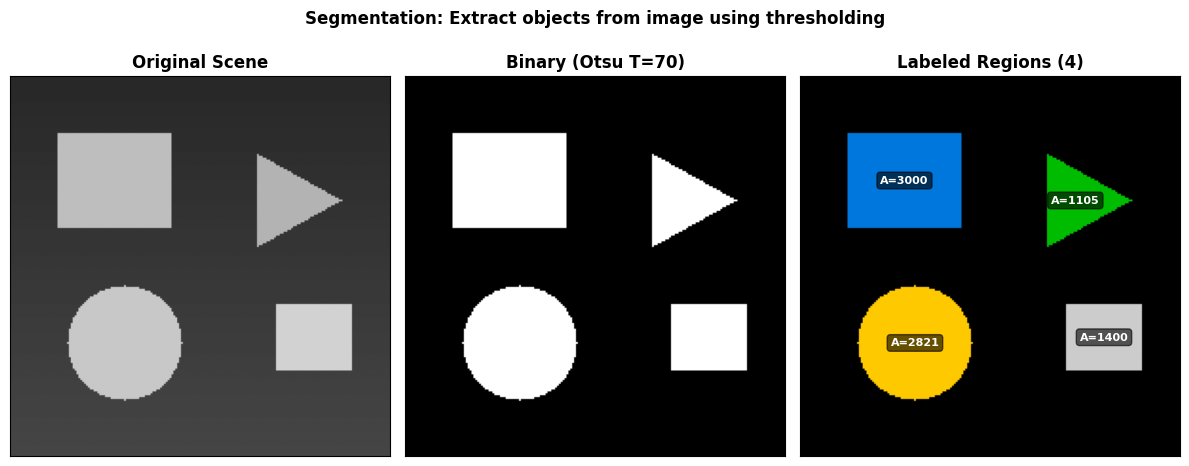

Otsu threshold: 70
Detected 4 connected regions

Saved: step1_segmentation_binary.png


In [3]:
# ============================================================
# 步骤 1：分割与二值图像
# Step 1: Segmentation and Binary Images
# ============================================================
print("=" * 60)
print("Step 1: Segmentation and Binary Images")
print("=" * 60)

scene = create_scene_image()

# Otsu自动阈值 / Otsu auto threshold
otsu_t = otsu_threshold(scene)
binary_scene = (scene > otsu_t).astype(np.uint8) * MAX_PIXEL_VALUE

# 标记连通区域 / Label connected regions
labeled, num_features = ndimage.label(binary_scene > 0)

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))

axes[0].set_title("Original Scene", fontsize=12, fontweight='bold')
axes[0].imshow(scene, cmap='gray', vmin=0, vmax=255)

axes[1].set_title(f"Binary (Otsu T={otsu_t})", fontsize=12, fontweight='bold')
axes[1].imshow(binary_scene, cmap='gray', vmin=0, vmax=255)

axes[2].set_title(f"Labeled Regions ({num_features})", fontsize=12, fontweight='bold')
axes[2].imshow(labeled, cmap='nipy_spectral')
# 标注每个区域面积 / Annotate each region's area
for region_id in range(1, num_features + 1):
    region_mask = labeled == region_id
    area = region_mask.sum()
    ys, xs = np.where(region_mask)
    cy, cx = ys.mean(), xs.mean()
    axes[2].text(cx, cy, f"A={area}", ha='center', va='center',
                 fontsize=8, color='white', fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Segmentation: Extract objects from image using thresholding",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step1_segmentation_binary.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Otsu threshold: {otsu_t}")
print(f"Detected {num_features} connected regions")
print("\nSaved: step1_segmentation_binary.png")


Step 2: Basic vs Adaptive Thresholding


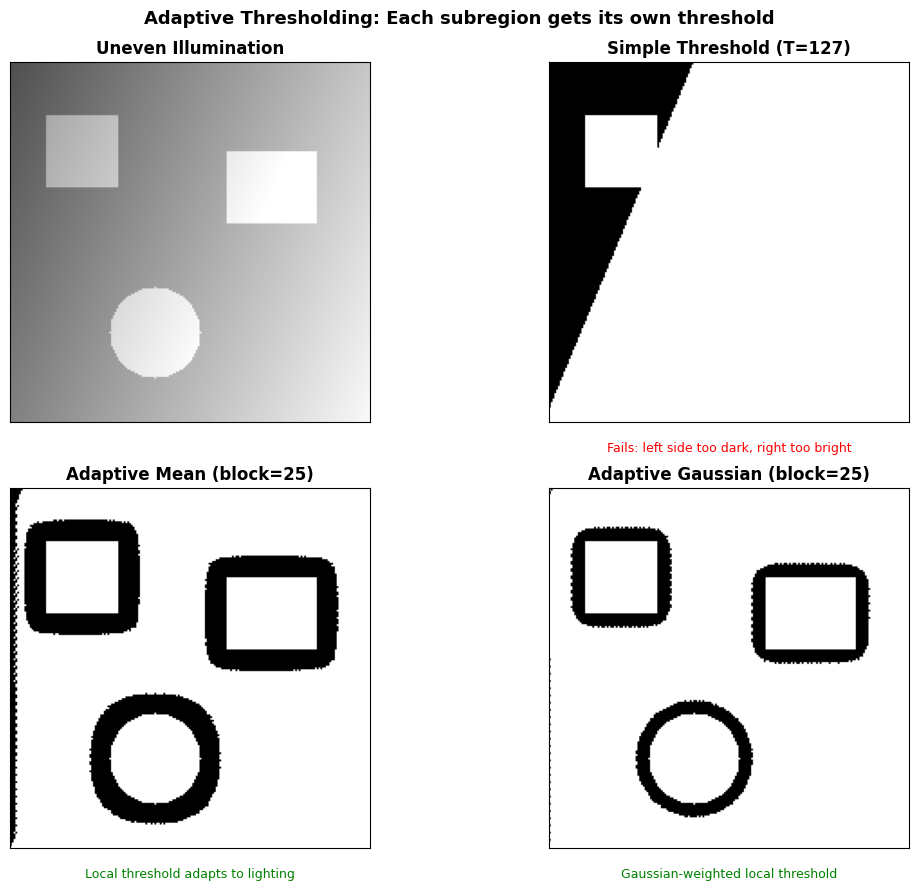

Simple threshold (T=127): fails under uneven lighting
Adaptive mean (block=25): adapts to local neighborhood
Adaptive Gaussian: Gaussian-weighted local threshold

Saved: step2_adaptive_threshold.png


In [4]:
# ============================================================
# 步骤 2：基本阈值 vs 自适应阈值
# Step 2: Basic vs Adaptive Thresholding
# ============================================================
print("\n" + "=" * 60)
print("Step 2: Basic vs Adaptive Thresholding")
print("=" * 60)

uneven = create_uneven_light_image()

# 简单全局阈值 / Simple global threshold
simple_binary = (uneven > SIMPLE_THRESHOLD).astype(np.uint8) * MAX_PIXEL_VALUE

# 自适应阈值（局部均值法）/ Adaptive threshold (local mean)
local_mean = ndimage.uniform_filter(uneven.astype(np.float64), size=ADAPTIVE_BLOCK_SIZE)
adaptive_mean = (uneven > (local_mean - 2)).astype(np.uint8) * MAX_PIXEL_VALUE

# 自适应阈值（高斯加权）/ Adaptive threshold (Gaussian weighted)
local_gauss = ndimage.gaussian_filter(uneven.astype(np.float64), sigma=ADAPTIVE_BLOCK_SIZE // 6)
adaptive_gauss = (uneven > (local_gauss - 2)).astype(np.uint8) * MAX_PIXEL_VALUE

fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH, FIG_HEIGHT + 1))

axes[0, 0].set_title("Uneven Illumination", fontsize=12, fontweight='bold')
axes[0, 0].imshow(uneven, cmap='gray', vmin=0, vmax=255)

axes[0, 1].set_title(f"Simple Threshold (T={SIMPLE_THRESHOLD})", fontsize=12, fontweight='bold')
axes[0, 1].imshow(simple_binary, cmap='gray', vmin=0, vmax=255)
axes[0, 1].text(0.5, -0.08, "Fails: left side too dark, right too bright",
                ha='center', fontsize=9, color='red', transform=axes[0, 1].transAxes)

axes[1, 0].set_title(f"Adaptive Mean (block={ADAPTIVE_BLOCK_SIZE})", fontsize=12, fontweight='bold')
axes[1, 0].imshow(adaptive_mean, cmap='gray', vmin=0, vmax=255)
axes[1, 0].text(0.5, -0.08, "Local threshold adapts to lighting",
                ha='center', fontsize=9, color='green', transform=axes[1, 0].transAxes)

axes[1, 1].set_title(f"Adaptive Gaussian (block={ADAPTIVE_BLOCK_SIZE})", fontsize=12, fontweight='bold')
axes[1, 1].imshow(adaptive_gauss, cmap='gray', vmin=0, vmax=255)
axes[1, 1].text(0.5, -0.08, "Gaussian-weighted local threshold",
                ha='center', fontsize=9, color='green', transform=axes[1, 1].transAxes)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Adaptive Thresholding: Each subregion gets its own threshold",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step2_adaptive_threshold.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Simple threshold (T={SIMPLE_THRESHOLD}): fails under uneven lighting")
print(f"Adaptive mean (block={ADAPTIVE_BLOCK_SIZE}): adapts to local neighborhood")
print(f"Adaptive Gaussian: Gaussian-weighted local threshold")
print("\nSaved: step2_adaptive_threshold.png")


Step 3: Contour Detection


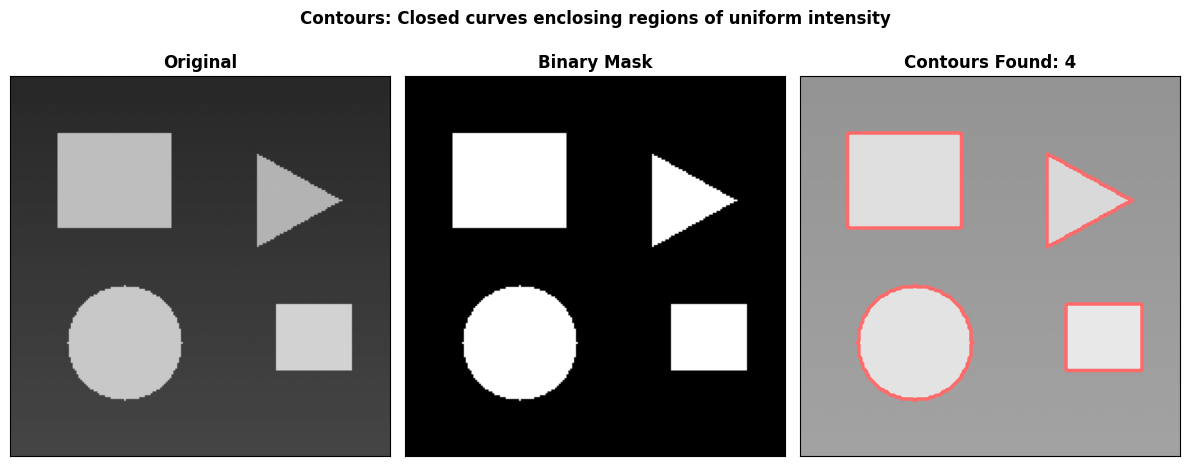

Found 4 contours in the binary image
Contours = closed curves enclosing regions of similar intensity
In OpenCV: cv2.findContours() returns boundary point lists
           cv2.drawContours() renders them on images

Saved: step3_contour_detection.png


In [5]:
# ============================================================
# 步骤 3：轮廓检测
# Step 3: Contour Detection
# ============================================================
print("\n" + "=" * 60)
print("Step 3: Contour Detection")
print("=" * 60)

binary_for_contour = (scene > otsu_t).astype(np.float64)

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))

axes[0].set_title("Original", fontsize=12, fontweight='bold')
axes[0].imshow(scene, cmap='gray', vmin=0, vmax=255)

axes[1].set_title("Binary Mask", fontsize=12, fontweight='bold')
axes[1].imshow(binary_for_contour, cmap='gray')

# 使用matplotlib的contour函数查找轮廓
# Use matplotlib's contour function to find contours
axes[2].set_title("Contours Overlaid", fontsize=12, fontweight='bold')
axes[2].imshow(scene, cmap='gray', vmin=0, vmax=255, alpha=0.5)
contour_set = axes[2].contour(binary_for_contour, levels=[0.5],
                               colors=['#FF6B6B'], linewidths=2.5)
# 计算轮廓数量（兼容不同matplotlib版本）
# Count contours (compatible with different matplotlib versions)
try:
    num_contours = len(contour_set.allsegs[0])
except (AttributeError, IndexError):
    num_contours = sum(1 for p in contour_set.get_paths())
axes[2].set_title(f"Contours Found: {num_contours}", fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Contours: Closed curves enclosing regions of uniform intensity",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step3_contour_detection.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Found {num_contours} contours in the binary image")
print("Contours = closed curves enclosing regions of similar intensity")
print("In OpenCV: cv2.findContours() returns boundary point lists")
print("           cv2.drawContours() renders them on images")
print("\nSaved: step3_contour_detection.png")


Step 4: Image Gradients — Measuring Intensity Change


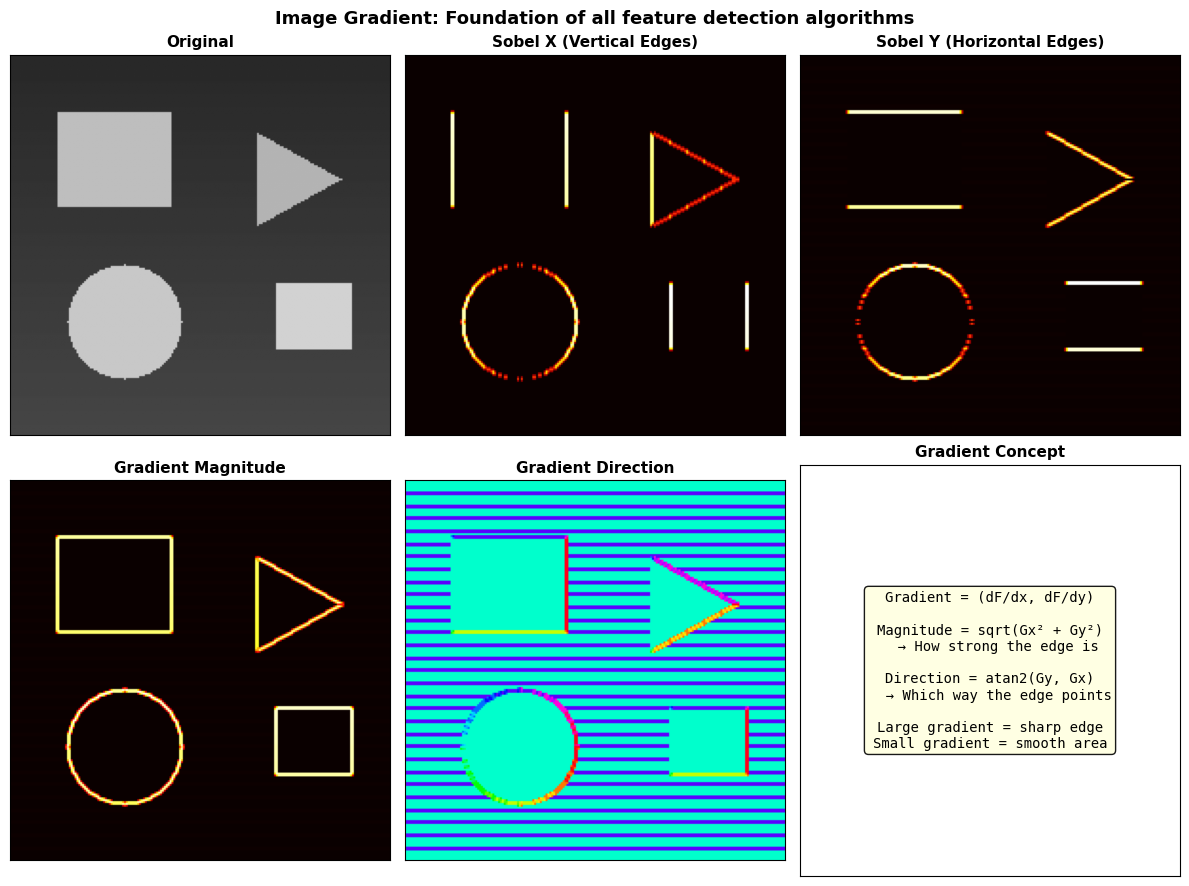

Sobel X detects vertical edges (horizontal intensity changes)
Sobel Y detects horizontal edges (vertical intensity changes)
Gradient magnitude range: [0.0, 647.7]

Saved: step4_image_gradients.png


In [6]:
# ============================================================
# 步骤 4：图像梯度（Sobel算子）
# Step 4: Image Gradients (Sobel Operator)
# ============================================================
print("\n" + "=" * 60)
print("Step 4: Image Gradients — Measuring Intensity Change")
print("=" * 60)

scene_f = scene.astype(np.float64)

# Sobel梯度 / Sobel gradients
sobel_x = ndimage.sobel(scene_f, axis=1)
sobel_y = ndimage.sobel(scene_f, axis=0)
gradient_mag = np.hypot(sobel_x, sobel_y)
gradient_dir = np.arctan2(sobel_y, sobel_x)

fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, FIG_HEIGHT + 1))

axes[0, 0].set_title("Original", fontsize=11, fontweight='bold')
axes[0, 0].imshow(scene, cmap='gray', vmin=0, vmax=255)

axes[0, 1].set_title("Sobel X (Vertical Edges)", fontsize=11, fontweight='bold')
axes[0, 1].imshow(np.abs(sobel_x), cmap='hot')

axes[0, 2].set_title("Sobel Y (Horizontal Edges)", fontsize=11, fontweight='bold')
axes[0, 2].imshow(np.abs(sobel_y), cmap='hot')

axes[1, 0].set_title("Gradient Magnitude", fontsize=11, fontweight='bold')
axes[1, 0].imshow(gradient_mag, cmap='hot')

axes[1, 1].set_title("Gradient Direction", fontsize=11, fontweight='bold')
axes[1, 1].imshow(gradient_dir, cmap='hsv')

axes[1, 2].set_title("Gradient Concept", fontsize=11, fontweight='bold')
axes[1, 2].text(0.5, 0.5,
                "Gradient = (dF/dx, dF/dy)\n\n"
                "Magnitude = sqrt(Gx² + Gy²)\n"
                "  → How strong the edge is\n\n"
                "Direction = atan2(Gy, Gx)\n"
                "  → Which way the edge points\n\n"
                "Large gradient = sharp edge\n"
                "Small gradient = smooth area",
                ha='center', va='center', fontsize=10,
                transform=axes[1, 2].transAxes, fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[1, 2].set_xticks([])
axes[1, 2].set_yticks([])

for ax in axes.flat:
    if len(ax.images) > 0:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Image Gradient: Foundation of all feature detection algorithms",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step4_image_gradients.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Sobel X detects vertical edges (horizontal intensity changes)")
print("Sobel Y detects horizontal edges (vertical intensity changes)")
print(f"Gradient magnitude range: [{gradient_mag.min():.1f}, {gradient_mag.max():.1f}]")
print("\nSaved: step4_image_gradients.png")


Step 5: SIFT Concepts — Scale Space and Keypoint Detection


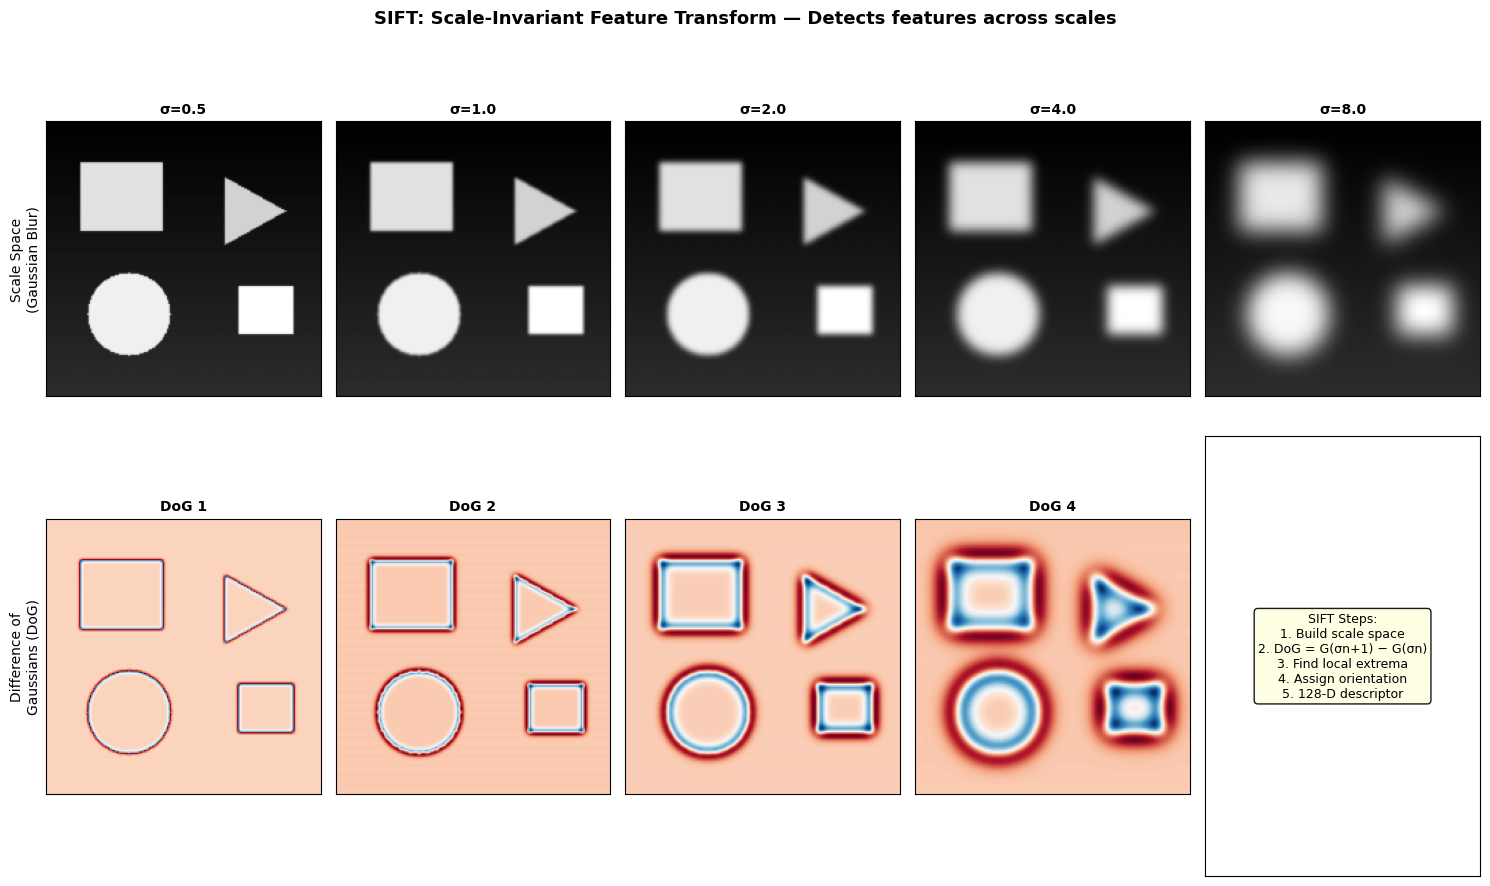

Scale space: Gaussian blur at increasing σ values
DoG (Difference of Gaussians): approximates Laplacian of Gaussian
Keypoints found at local extrema in DoG across scales
SIFT descriptor: 128-D vector (4×4 blocks × 8 orientations)

Saved: step5_sift_scale_space.png


In [7]:
# ============================================================
# 步骤 5：SIFT概念演示（尺度空间 + DoG）
# Step 5: SIFT Concept Demo (Scale Space + DoG)
# ============================================================
print("\n" + "=" * 60)
print("Step 5: SIFT Concepts — Scale Space and Keypoint Detection")
print("=" * 60)

# 模拟尺度空间：不同sigma的高斯模糊
# Simulate scale space: Gaussian blur at different sigma levels
sigmas = [0.5, 1.0, 2.0, 4.0, 8.0]
scale_space = [ndimage.gaussian_filter(scene_f, sigma=s) for s in sigmas]

# DoG（高斯差分）= 相邻尺度相减
# DoG (Difference of Gaussians) = subtract adjacent scales
dogs = [scale_space[i + 1] - scale_space[i] for i in range(len(scale_space) - 1)]

fig, axes = plt.subplots(2, 5, figsize=(FIG_WIDTH + 3, FIG_HEIGHT + 1))

# 上排：尺度空间 / Top row: Scale space
for i, (s_img, sigma) in enumerate(zip(scale_space, sigmas)):
    axes[0, i].set_title(f"σ={sigma}", fontsize=10, fontweight='bold')
    axes[0, i].imshow(s_img, cmap='gray')
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
axes[0, 0].set_ylabel("Scale Space\n(Gaussian Blur)", fontsize=10)

# 下排：DoG / Bottom row: DoG
for i, dog_img in enumerate(dogs):
    axes[1, i].set_title(f"DoG {i + 1}", fontsize=10, fontweight='bold')
    axes[1, i].imshow(dog_img, cmap='RdBu_r')
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
axes[1, 0].set_ylabel("Difference of\nGaussians (DoG)", fontsize=10)

# 最后一列放说明 / Last column: explanation
axes[1, 4].text(0.5, 0.5,
                "SIFT Steps:\n"
                "1. Build scale space\n"
                "2. DoG = G(σn+1) − G(σn)\n"
                "3. Find local extrema\n"
                "4. Assign orientation\n"
                "5. 128-D descriptor",
                ha='center', va='center', fontsize=9,
                transform=axes[1, 4].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[1, 4].set_xticks([])
axes[1, 4].set_yticks([])

plt.suptitle("SIFT: Scale-Invariant Feature Transform — Detects features across scales",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step5_sift_scale_space.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Scale space: Gaussian blur at increasing σ values")
print("DoG (Difference of Gaussians): approximates Laplacian of Gaussian")
print("Keypoints found at local extrema in DoG across scales")
print("SIFT descriptor: 128-D vector (4×4 blocks × 8 orientations)")
print("\nSaved: step5_sift_scale_space.png")


Step 6: Harris Corner Detection


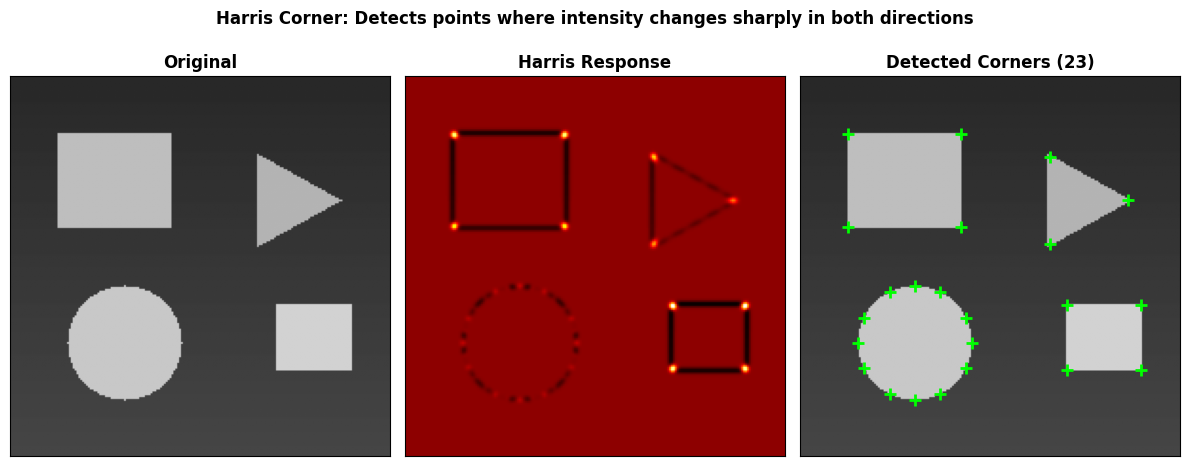

Harris corner detection (k=0.05, σ=1.5)
Detected 23 corners
R = det(M) - k * trace(M)²
  Edge: one eigenvalue large → R < 0
  Flat: both small → R ≈ 0
  Corner: both large → R >> 0

Saved: step6_harris_corners.png


In [8]:
# ============================================================
# 步骤 6：Harris角点检测
# Step 6: Harris Corner Detection
# ============================================================
print("\n" + "=" * 60)
print("Step 6: Harris Corner Detection")
print("=" * 60)

harris_resp, corners = harris_corners(scene)

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))

axes[0].set_title("Original", fontsize=12, fontweight='bold')
axes[0].imshow(scene, cmap='gray', vmin=0, vmax=255)

axes[1].set_title("Harris Response", fontsize=12, fontweight='bold')
axes[1].imshow(harris_resp, cmap='hot')

axes[2].set_title(f"Detected Corners ({len(corners)})", fontsize=12, fontweight='bold')
axes[2].imshow(scene, cmap='gray', vmin=0, vmax=255)
if len(corners) > 0:
    axes[2].scatter(corners[:, 1], corners[:, 0], c='lime', s=80,
                     marker='+', linewidths=2, zorder=5)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Harris Corner: Detects points where intensity changes sharply in both directions",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step6_harris_corners.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Harris corner detection (k={HARRIS_K}, σ={HARRIS_SIGMA})")
print(f"Detected {len(corners)} corners")
print("R = det(M) - k * trace(M)²")
print("  Edge: one eigenvalue large → R < 0")
print("  Flat: both small → R ≈ 0")
print("  Corner: both large → R >> 0")
print("\nSaved: step6_harris_corners.png")


Step 7: Feature Detector Comparison (SIFT vs SURF vs ORB)


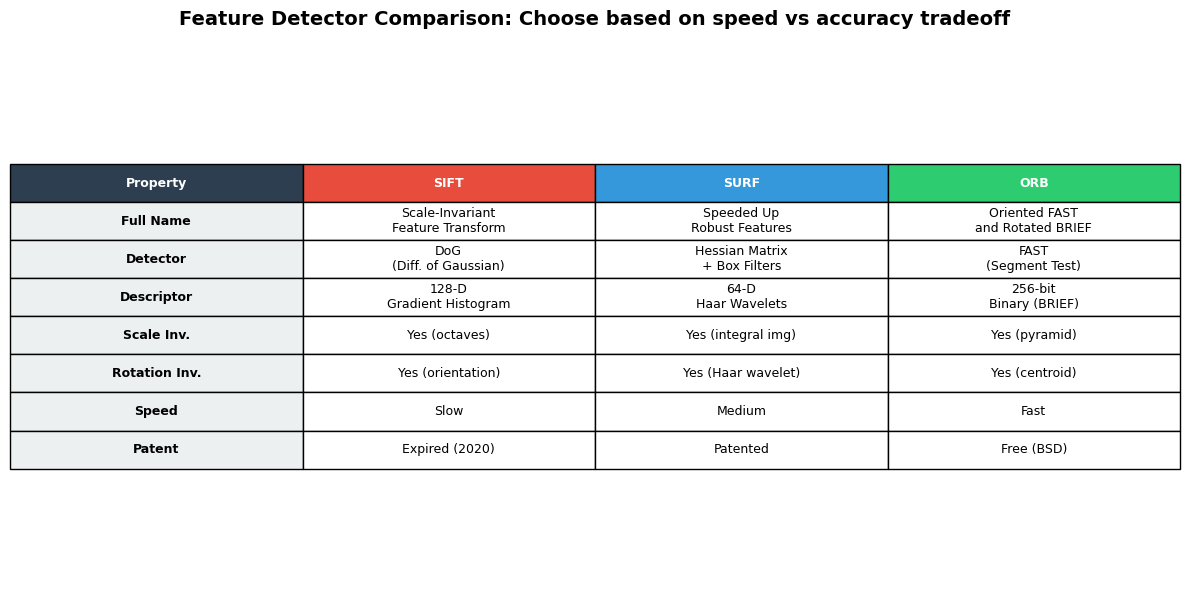

SIFT: Most accurate, slowest, 128-D descriptor, patent expired 2020
SURF: Faster than SIFT, 64-D descriptor, uses integral images
ORB: Fastest, binary descriptor (256-bit), free to use

Saved: step7_detector_comparison.png


In [9]:
# ============================================================
# 步骤 7：SIFT vs SURF vs ORB 概念对比
# Step 7: SIFT vs SURF vs ORB Comparison
# ============================================================
print("\n" + "=" * 60)
print("Step 7: Feature Detector Comparison (SIFT vs SURF vs ORB)")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))
ax.axis('off')

table_data = [
    ["Property", "SIFT", "SURF", "ORB"],
    ["Full Name", "Scale-Invariant\nFeature Transform", "Speeded Up\nRobust Features",
     "Oriented FAST\nand Rotated BRIEF"],
    ["Detector", "DoG\n(Diff. of Gaussian)", "Hessian Matrix\n+ Box Filters",
     "FAST\n(Segment Test)"],
    ["Descriptor", "128-D\nGradient Histogram", "64-D\nHaar Wavelets",
     "256-bit\nBinary (BRIEF)"],
    ["Scale Inv.", "Yes (octaves)", "Yes (integral img)", "Yes (pyramid)"],
    ["Rotation Inv.", "Yes (orientation)", "Yes (Haar wavelet)", "Yes (centroid)"],
    ["Speed", "Slow", "Medium", "Fast"],
    ["Patent", "Expired (2020)", "Patented", "Free (BSD)"],
]

colors_header = ['#2C3E50', '#E74C3C', '#3498DB', '#2ECC71']
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 2.0)

for j in range(4):
    table[0, j].set_facecolor(colors_header[j])
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data)):
    for j in range(4):
        if j == 0:
            table[i, j].set_facecolor('#ECF0F1')
            table[i, j].set_text_props(fontweight='bold')

ax.set_title("Feature Detector Comparison: Choose based on speed vs accuracy tradeoff",
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step7_detector_comparison.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("SIFT: Most accurate, slowest, 128-D descriptor, patent expired 2020")
print("SURF: Faster than SIFT, 64-D descriptor, uses integral images")
print("ORB: Fastest, binary descriptor (256-bit), free to use")
print("\nSaved: step7_detector_comparison.png")


Step 8: HOG — Histogram of Oriented Gradients


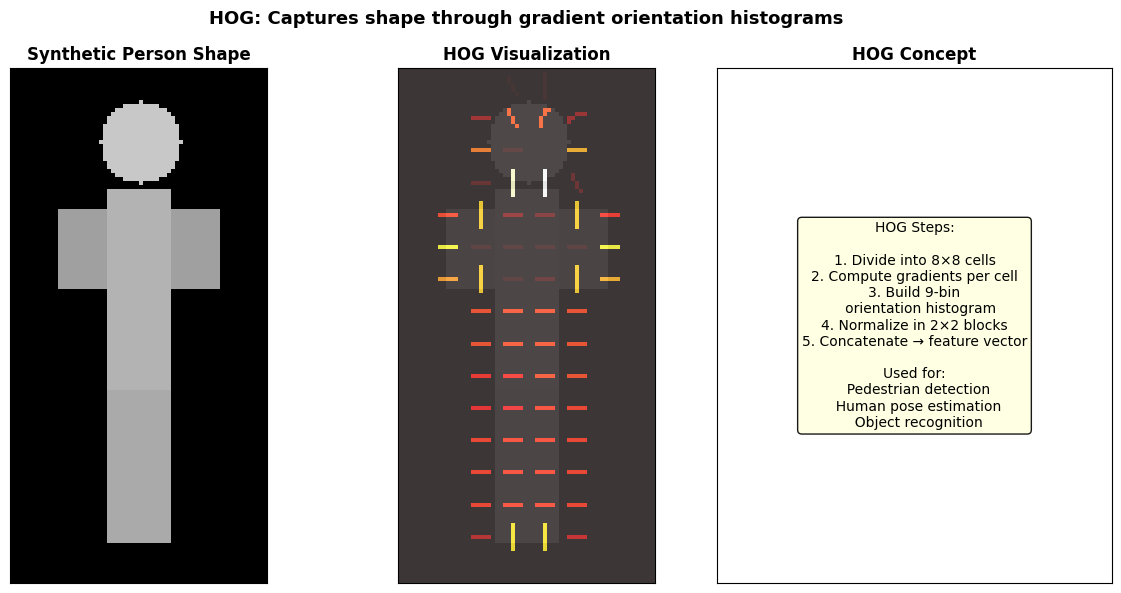

Image size: 128×64
Cell size: 8×8 → 16×8 = 128 cells
Orientations per cell: 9
HOG is especially effective for pedestrian/human detection

Saved: step8_hog_descriptor.png


In [10]:
# ============================================================
# 步骤 8：HOG特征描述子
# Step 8: HOG (Histogram of Oriented Gradients) Descriptor
# ============================================================
print("\n" + "=" * 60)
print("Step 8: HOG — Histogram of Oriented Gradients")
print("=" * 60)

# 创建简单人形图像 / Create simple human-like shape
person_h, person_w = 128, 64
person_img = np.zeros((person_h, person_w), dtype=np.float64)
# 头 / Head
yy, xx = np.ogrid[:person_h, :person_w]
head_mask = (xx - 32) ** 2 + (yy - 18) ** 2 <= 10 ** 2
person_img[head_mask] = 200
# 身体 / Body
person_img[30:80, 24:40] = 180
# 手臂 / Arms
person_img[35:55, 12:24] = 160
person_img[35:55, 40:52] = 160
# 腿 / Legs
person_img[80:118, 24:32] = 170
person_img[80:118, 32:40] = 170
person_img = person_img.astype(np.uint8)

# 手动计算HOG可视化 / Manually compute HOG visualization
# 计算梯度 / Compute gradients
gx = ndimage.sobel(person_img.astype(np.float64), axis=1)
gy = ndimage.sobel(person_img.astype(np.float64), axis=0)
mag = np.hypot(gx, gy)
ang = np.degrees(np.arctan2(gy, gx)) % 180

# 按cell计算方向直方图 / Compute orientation histograms per cell
cells_y = person_h // HOG_CELL_SIZE
cells_x = person_w // HOG_CELL_SIZE
hog_vis = np.zeros_like(person_img, dtype=np.float64)

total_features = 0
for cy in range(cells_y):
    for cx in range(cells_x):
        y0 = cy * HOG_CELL_SIZE
        x0 = cx * HOG_CELL_SIZE
        cell_mag = mag[y0:y0 + HOG_CELL_SIZE, x0:x0 + HOG_CELL_SIZE]
        cell_ang = ang[y0:y0 + HOG_CELL_SIZE, x0:x0 + HOG_CELL_SIZE]

        # 构建方向直方图 / Build orientation histogram
        hist = np.zeros(HOG_ORIENTATIONS)
        bin_width = 180.0 / HOG_ORIENTATIONS
        for a, m in zip(cell_ang.flatten(), cell_mag.flatten()):
            bin_idx = int(a / bin_width) % HOG_ORIENTATIONS
            hist[bin_idx] += m

        # 可视化：绘制主方向的线 / Visualize: draw line for dominant orientation
        if hist.max() > 0:
            dominant_bin = np.argmax(hist)
            angle_rad = np.radians(dominant_bin * bin_width + bin_width / 2)
            center_y = y0 + HOG_CELL_SIZE // 2
            center_x = x0 + HOG_CELL_SIZE // 2
            length = HOG_CELL_SIZE // 2 - 1
            dy = int(np.sin(angle_rad) * length)
            dx = int(np.cos(angle_rad) * length)
            # 简易线段绘制 / Simple line drawing
            for t in np.linspace(0, 1, HOG_CELL_SIZE):
                py = int(center_y + dy * (t - 0.5) * 2)
                px = int(center_x + dx * (t - 0.5) * 2)
                if 0 <= py < person_h and 0 <= px < person_w:
                    hog_vis[py, px] = hist.max()
        total_features += HOG_ORIENTATIONS

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))

axes[0].set_title("Synthetic Person Shape", fontsize=12, fontweight='bold')
axes[0].imshow(person_img, cmap='gray', vmin=0, vmax=255)

axes[1].set_title("HOG Visualization", fontsize=12, fontweight='bold')
axes[1].imshow(person_img, cmap='gray', vmin=0, vmax=255, alpha=0.3)
axes[1].imshow(hog_vis, cmap='hot', alpha=0.7)

axes[2].set_title("HOG Concept", fontsize=12, fontweight='bold')
axes[2].text(0.5, 0.5,
             "HOG Steps:\n\n"
             f"1. Divide into {HOG_CELL_SIZE}×{HOG_CELL_SIZE} cells\n"
             "2. Compute gradients per cell\n"
             f"3. Build {HOG_ORIENTATIONS}-bin\n   orientation histogram\n"
             "4. Normalize in 2×2 blocks\n"
             f"5. Concatenate → feature vector\n\n"
             "Used for:\n"
             "  Pedestrian detection\n"
             "  Human pose estimation\n"
             "  Object recognition",
             ha='center', va='center', fontsize=10,
             transform=axes[2].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[2].set_xticks([])
axes[2].set_yticks([])

for ax in axes[:2]:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("HOG: Captures shape through gradient orientation histograms",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step8_hog_descriptor.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Image size: {person_h}×{person_w}")
print(f"Cell size: {HOG_CELL_SIZE}×{HOG_CELL_SIZE} → {cells_y}×{cells_x} = {cells_y * cells_x} cells")
print(f"Orientations per cell: {HOG_ORIENTATIONS}")
print("HOG is especially effective for pedestrian/human detection")
print("\nSaved: step8_hog_descriptor.png")


Step 9: Feature Matching — Finding Correspondences


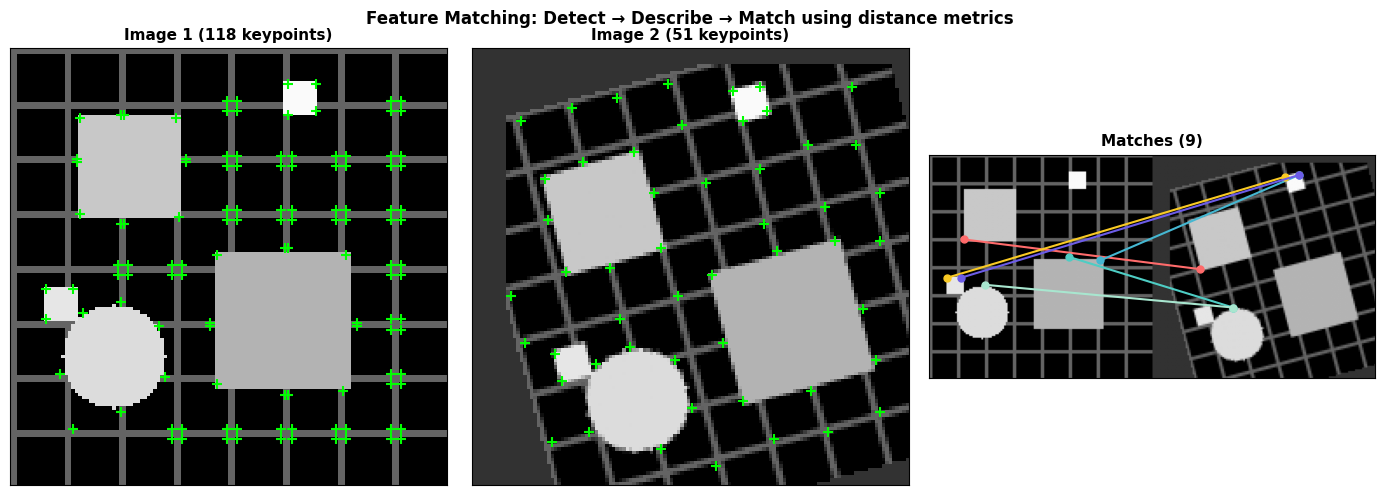

Image 1: 118 keypoints detected
Image 2: 51 keypoints detected
Matches found: 9 (Lowe's ratio test, threshold=0.8)
Matching methods: Brute-Force, BF-KNN, FLANN
Distance metrics: Euclidean (float), Hamming (binary)

Saved: step9_feature_matching.png


In [11]:
# ============================================================
# 步骤 9：特征匹配概念
# Step 9: Feature Matching Concepts
# ============================================================
print("\n" + "=" * 60)
print("Step 9: Feature Matching — Finding Correspondences")
print("=" * 60)

img1, img2 = create_textured_pair()

# 用Harris角点作为特征点 / Use Harris corners as feature points
_, corners1 = harris_corners(img1, threshold_rel=0.02)
_, corners2 = harris_corners(img2, threshold_rel=0.02)

# 简易描述子：取角点周围patch并归一化
# Simple descriptor: normalized patch around each corner
def get_patch_descriptors(img, kps, half=MATCH_PATCH_HALF):
    """Extract normalized patch descriptors around each keypoint."""
    descs = []
    valid_kps = []
    for y, x in kps:
        if half <= y < img.shape[0] - half and half <= x < img.shape[1] - half:
            patch = img[y - half:y + half + 1, x - half:x + half + 1].flatten().astype(np.float64)
            norm = np.linalg.norm(patch)
            if norm > 0:
                patch = patch / norm
            descs.append(patch)
            valid_kps.append((y, x))
    return np.array(valid_kps), np.array(descs) if descs else np.empty((0, (2 * half + 1) ** 2))

kps1, descs1 = get_patch_descriptors(img1, corners1)
kps2, descs2 = get_patch_descriptors(img2, corners2)

# 暴力匹配 + Lowe比率测试 / Brute-force matching + Lowe's ratio test
matches = []
if len(descs1) > 0 and len(descs2) > 0:
    for i in range(len(descs1)):
        # 计算到所有描述子的欧氏距离
        # Compute Euclidean distance to all descriptors
        dists = np.linalg.norm(descs2 - descs1[i], axis=1)
        sorted_idx = np.argsort(dists)
        if len(sorted_idx) >= 2:
            # Lowe比率测试：最近距离 < 0.8 × 第二近距离
            # Lowe's ratio test: nearest < 0.8 × second nearest
            if dists[sorted_idx[0]] < LOWE_RATIO * dists[sorted_idx[1]]:
                matches.append((i, sorted_idx[0], dists[sorted_idx[0]]))

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH + 2, FIG_HEIGHT // 2 + 1))

axes[0].set_title(f"Image 1 ({len(kps1)} keypoints)", fontsize=11, fontweight='bold')
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
if len(kps1) > 0:
    axes[0].scatter(kps1[:, 1], kps1[:, 0], c='lime', s=50, marker='+', linewidths=1.5)

axes[1].set_title(f"Image 2 ({len(kps2)} keypoints)", fontsize=11, fontweight='bold')
axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
if len(kps2) > 0:
    axes[1].scatter(kps2[:, 1], kps2[:, 0], c='lime', s=50, marker='+', linewidths=1.5)

# 并排匹配可视化 / Side-by-side match visualization
combined = np.hstack([img1, img2])
axes[2].set_title(f"Matches ({len(matches)})", fontsize=11, fontweight='bold')
axes[2].imshow(combined, cmap='gray', vmin=0, vmax=255)
match_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F9CA24', '#6C5CE7', '#A8E6CF']
for idx, (i, j, d) in enumerate(matches[:6]):
    y1, x1 = kps1[i]
    y2, x2 = kps2[j]
    color = match_colors[idx % len(match_colors)]
    axes[2].plot([x1, x2 + img1.shape[1]], [y1, y2], '-', color=color, linewidth=1.5)
    axes[2].plot(x1, y1, 'o', color=color, markersize=5)
    axes[2].plot(x2 + img1.shape[1], y2, 'o', color=color, markersize=5)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Feature Matching: Detect → Describe → Match using distance metrics",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step9_feature_matching.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Image 1: {len(kps1)} keypoints detected")
print(f"Image 2: {len(kps2)} keypoints detected")
print(f"Matches found: {len(matches)} (Lowe's ratio test, threshold={LOWE_RATIO})")
print("Matching methods: Brute-Force, BF-KNN, FLANN")
print("Distance metrics: Euclidean (float), Hamming (binary)")
print("\nSaved: step9_feature_matching.png")


Step 10: Feature Detection Pipeline Summary


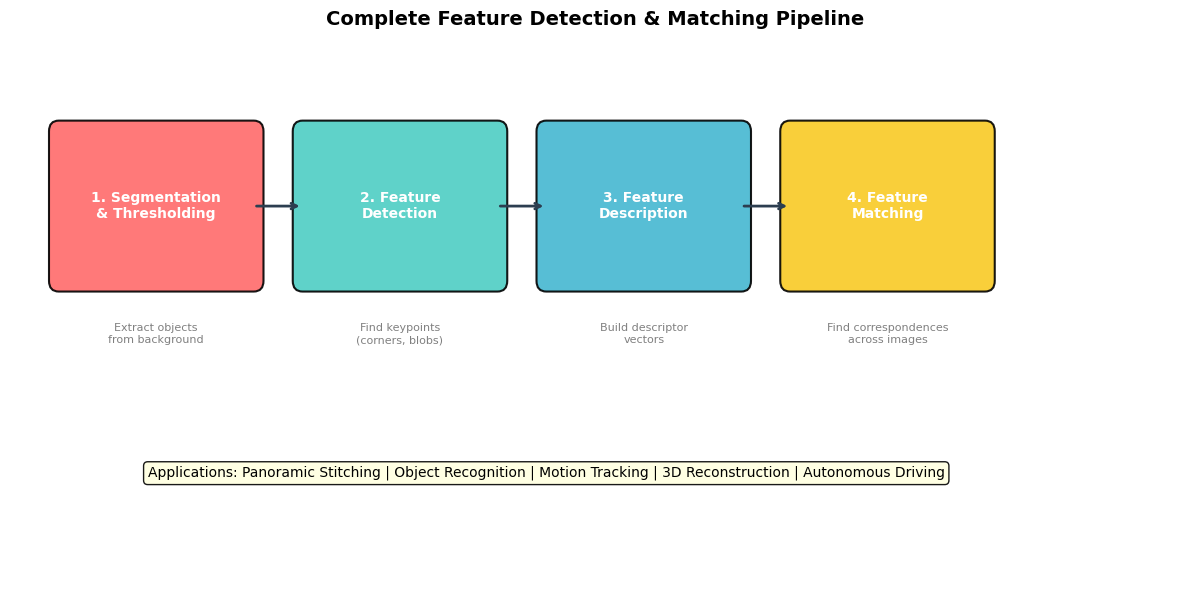

Feature detection pipeline:
  1. Segmentation — separate objects from background
  2. Detection — find interesting keypoints (SIFT, SURF, ORB, Harris)
  3. Description — encode keypoint neighborhoods as vectors
  4. Matching — compare descriptors across images

Applications: panoramic stitching, object recognition, motion tracking

Saved: step10_pipeline_summary.png

All demos completed successfully!
Output directory: D:\BaiduSyncdisk\workspace\python_workspace_2025\aisd\courses\mv\notes\week3_feature_detection_complete_demo_pages


In [12]:
# ============================================================
# 步骤 10：特征检测流程总结
# Step 10: Feature Detection Pipeline Summary
# ============================================================
print("\n" + "=" * 60)
print("Step 10: Feature Detection Pipeline Summary")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis('off')

stages = [
    (1.5, 3.5, "1. Segmentation\n& Thresholding", '#FF6B6B',
     "Extract objects\nfrom background"),
    (4.0, 3.5, "2. Feature\nDetection", '#4ECDC4',
     "Find keypoints\n(corners, blobs)"),
    (6.5, 3.5, "3. Feature\nDescription", '#45B7D1',
     "Build descriptor\nvectors"),
    (9.0, 3.5, "4. Feature\nMatching", '#F9CA24',
     "Find correspondences\nacross images"),
]

for x, y, text, color, desc in stages:
    rect = mpatches.FancyBboxPatch((x - 1.0, y - 0.7), 2.0, 1.4,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='black',
                                    linewidth=1.5, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white')
    ax.text(x, y - 1.2, desc, ha='center', va='center', fontsize=8, color='gray')

# 箭头 / Arrows
arrow_style = dict(arrowstyle='->', color='#2C3E50', lw=2)
for i in range(3):
    x_start = stages[i][0] + 1.0
    x_end = stages[i + 1][0] - 1.0
    ax.annotate('', xy=(x_end, 3.5), xytext=(x_start, 3.5), arrowprops=arrow_style)

apps_text = ("Applications: Panoramic Stitching | Object Recognition | "
             "Motion Tracking | 3D Reconstruction | Autonomous Driving")
ax.text(5.5, 1.0, apps_text, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_title("Complete Feature Detection & Matching Pipeline",
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step10_pipeline_summary.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Feature detection pipeline:")
print("  1. Segmentation — separate objects from background")
print("  2. Detection — find interesting keypoints (SIFT, SURF, ORB, Harris)")
print("  3. Description — encode keypoint neighborhoods as vectors")
print("  4. Matching — compare descriptors across images")
print("\nApplications: panoramic stitching, object recognition, motion tracking")
print("\nSaved: step10_pipeline_summary.png")

# ============================================================
# 完成
# Done
# ============================================================

print("\n" + "=" * 60)
print("All demos completed successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print("=" * 60)